# Práctica: Piezas de Lego
**a)** Contar piezas.  
**b)** Segmentar sólo las piezas verdes.

Pipeline de la Práctica 4: grayscale → Otsu → morph → fill holes → connected components.

> **Nota:** El conteo es aproximado (27 detectadas vs 29 reales). Dos pares de piezas se tocan con uniones gruesas (las 2 columnas blancas centrales y el ala + plana verde) y no se separan con morfología sin destruir piezas pequeñas. Separarlas requeriría watershed con marcadores manuales.

## 0. Configuración

In [11]:
ruta_img = "piezas.jpg"
area_min = 500
area_max = 25000

In [12]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

## 1. Cargar imagen

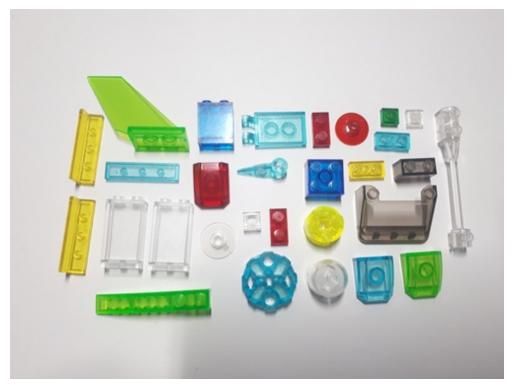

In [13]:
imagen = cv2.imread(ruta_img)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off');

## 2. Binarización (Otsu sobre gris)

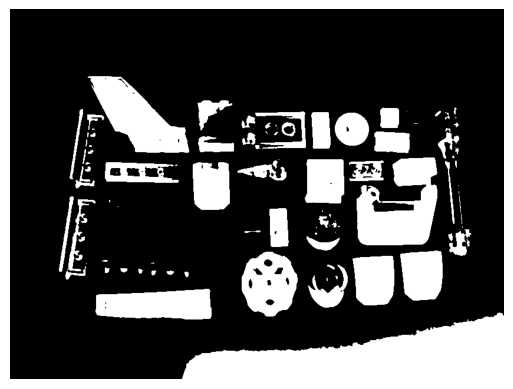

In [14]:
I = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
I = cv2.GaussianBlur(I, (5, 5), 0)
umbral, _ = cv2.threshold(I, 0, 255, cv2.THRESH_OTSU)
# Piezas más oscuras que el fondo claro
binaria = np.uint8((I < umbral) * 255)
plt.imshow(binaria, cmap='gray')
plt.axis('off');

## 3. Limpieza morfológica y rellenado de huecos

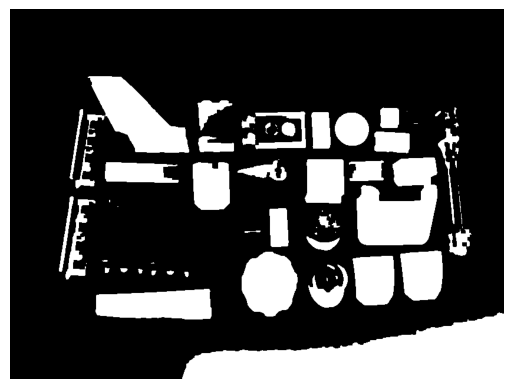

In [15]:
kernel = np.ones((5, 5), np.uint8)
binaria = cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, kernel)
binaria = ndimage.binary_fill_holes(binaria).astype(np.uint8) * 255
plt.imshow(binaria, cmap='gray')
plt.axis('off');

## 4. a) Conteo de piezas

In [16]:
n, etiquetas, stats, _ = cv2.connectedComponentsWithStats(binaria, 2, cv2.CV_32S)
# Filtro: descartar ruido (área < area_min) y la sombra del fondo (área > area_max)
indices = [i for i in range(1, n) if area_min <= stats[i, 4] <= area_max]
print(f"Piezas detectadas: {len(indices)}")

Piezas detectadas: 27


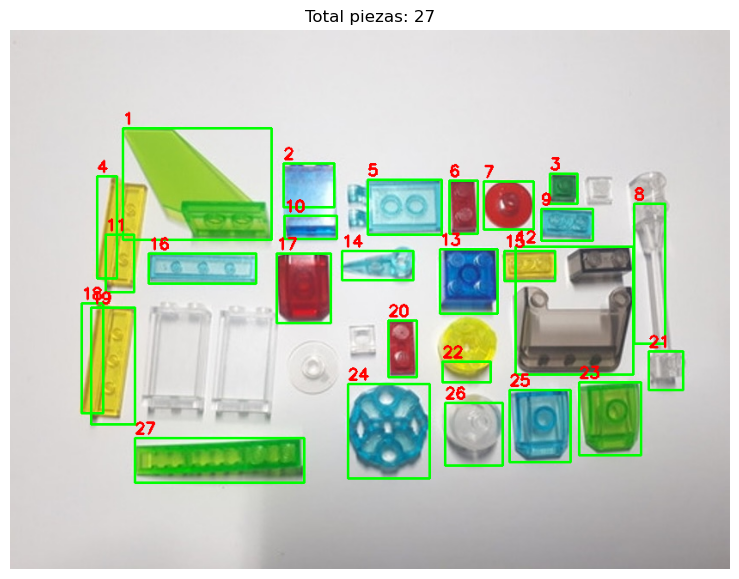

In [17]:
# Visualización del conteo con bounding box
conteo_img = imagen.copy()
for idx, i in enumerate(indices, start=1):
    x, y, w, h, _ = stats[i]
    cv2.rectangle(conteo_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(conteo_img, str(idx), (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(conteo_img, cv2.COLOR_BGR2RGB))
plt.title(f"Total piezas: {len(indices)}")
plt.axis('off');

## 5. b) Segmentación de piezas verdes (HSV)

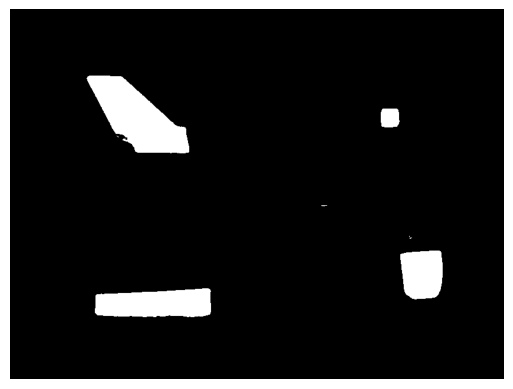

In [18]:
hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
# Rango de verde en HSV de OpenCV (H: 0-179)
verde_bajo = np.array([35, 50, 50])
verde_alto = np.array([85, 255, 255])
mascara_verde = cv2.inRange(hsv, verde_bajo, verde_alto)
plt.imshow(mascara_verde, cmap='gray')
plt.axis('off');

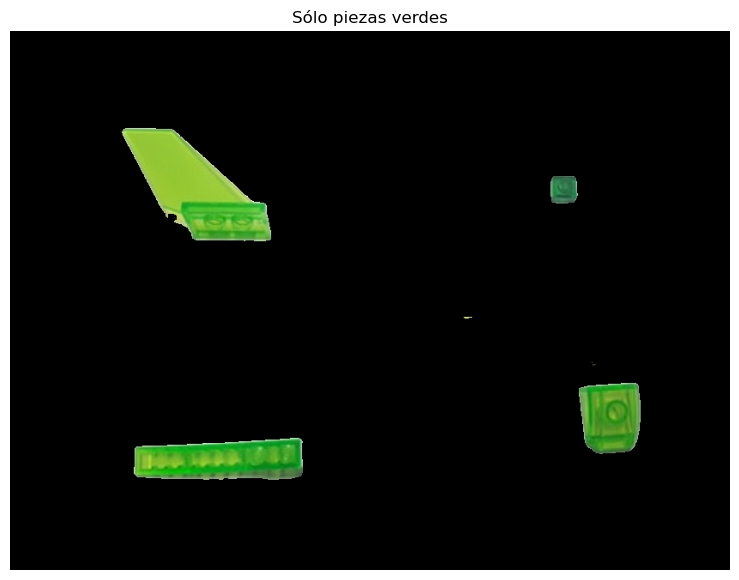

In [19]:
# Limpiar máscara y aplicarla a la imagen original
mascara_verde = cv2.morphologyEx(mascara_verde, cv2.MORPH_CLOSE, kernel)
solo_verde = cv2.bitwise_and(imagen, imagen, mask=mascara_verde)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(solo_verde, cv2.COLOR_BGR2RGB))
plt.title("Sólo piezas verdes")
plt.axis('off');

In [20]:
# Conteo extra: cuántas piezas verdes
n_v, _, stats_v, _ = cv2.connectedComponentsWithStats(mascara_verde, 2, cv2.CV_32S)
verdes = [i for i in range(1, n_v) if stats_v[i, 4] >= area_min]
print(f"Piezas verdes: {len(verdes)}")

Piezas verdes: 4


In [ ]:
#   ruta_img ← "piezas.jpg"
#   area_min ← 500
#   area_max ← 25000

#   // --- a) Conteo ---
#   imagen   ← leer(ruta_img)
#   gris     ← convertir_a_grises(imagen)
#   gris     ← suavizar_gauss(gris, 5x5), 5x5 es el tamaño del kernel
#   umbral   ← Otsu(gris)
#   binaria  ← (gris < umbral)
#   binaria  ← cierre_morfológico(binaria, 5x5), esto es para cerrar huecos pequeños
#   binaria  ← rellenar_huecos(binaria), esto es para asegurar que las piezas estén sólidas

#   componentes ← etiquetar_conectados(binaria)
#   piezas      ← filtrar(componentes, area_min ≤ área ≤ area_max)
#   imprimir("Piezas:", longitud(piezas))

#   // --- b) Verdes ---
#   hsv       ← convertir_a_HSV(imagen), lo pasamos a HSV (Hue, Saturation, Value) para facilitar la segmentación por color
#   m_verde   ← en_rango(hsv, H∈[35,85], S∈[50,255], V∈[50,255]), máscara binaria que marca los píxeles verdes
#   m_verde   ← cierre_morfológico(m_verde, 5x5), para limpiar la máscara
#   solo_verde ← imagen AND m_verde
#   mostrar(solo_verde)